### 13 - Sistemas de Recomendación - Tu futuro según la data ###

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Este proyecto propone construir un modelo de clasificación supervisada que, a partir de datos demográficos y socioeconómicos de una persona adulta (edad, nivel educativo, ocupación, estado civil, país de origen, etc.), prediga si dicha persona ganará más o menos de 50,000 USD al año.

En base a los resultados del modelo, los estudiantes deberán desarrollar un sistema de recomendación interpretativo, capaz de sugerir posibles estrategias o cambios para aumentar la probabilidad de superar ese umbral de ingresos.

Objetivos
- Explorar los datos del censo.
- Construir perfiles socioeconómicos.
- Explorar la importancia y peso de variables sociales (educación, género, raza, etc.) en predicciones económicas.
- Aplicar técnicas de sistemas de recomendación.
- Visualizar y comunicar hallazgos de forma profesional.

In [3]:
df = pd.read_csv('/workspaces/GuilloMansa-MachineLearning/data/raw/adult-census-income.csv')

In [ ]:
df

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,22,Private,310152,Some-college,10,Never-married,Protective-serv,Not-in-family,White,Male,0,0,40,United-States,<=50K
32557,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32558,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32559,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K


In [6]:
df.shape, df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


((32561, 15), None)

In [7]:
df.duplicated().sum()

np.int64(24)

In [11]:
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)

In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,32537.0,38.585549,13.637984,17.0,28.0,37.0,48.0,90.0
fnlwgt,32537.0,189780.848511,105556.471009,12285.0,117827.0,178356.0,236993.0,1484705.0
education.num,32537.0,10.081815,2.571633,1.0,9.0,10.0,12.0,16.0
capital.gain,32537.0,1078.443741,7387.957424,0.0,0.0,0.0,0.0,99999.0
capital.loss,32537.0,87.368227,403.101833,0.0,0.0,0.0,0.0,4356.0
hours.per.week,32537.0,40.440329,12.346889,1.0,40.0,40.0,45.0,99.0


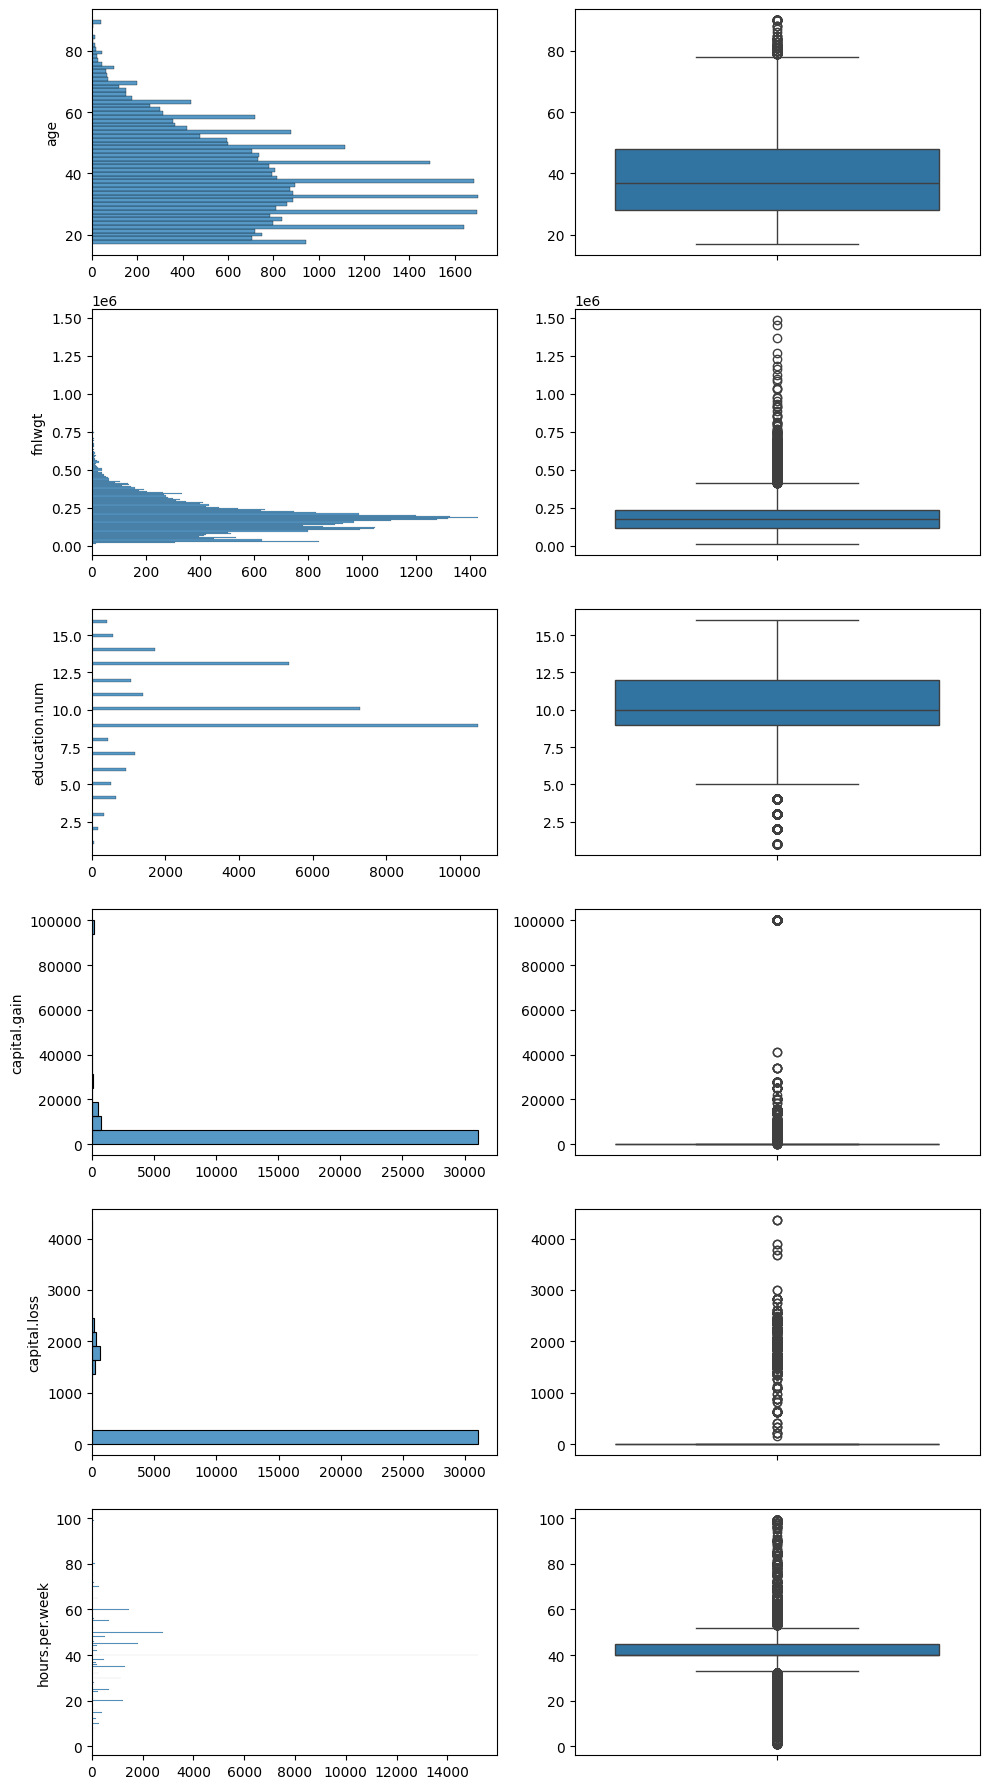

In [12]:
num_variables = df.select_dtypes(include=['int64','float64']).columns.tolist()


fig, axis = plt.subplots(len(num_variables), 2, figsize=(10, 3*len(num_variables)))

for i, var in enumerate(num_variables):
    sns.histplot(ax=axis[i, 0], data=df, y=var).set(xlabel=None)
    sns.boxplot(ax=axis[i, 1], data=df, y=var).set(ylabel=None)


plt.tight_layout()
plt.show()